# Customer Churn: Recommendations

This notebook is the final notebook in the customer churn project.

The goal is to combine the customer segment findings from the insights notebook with the machine learning results from the modeling notebook. The final output is a set of business recommendations for reducing customer churn.


## Project Notebooks

1. **Customer Churn: EDA**  
   Cleans the dataset, creates churn-related features, and explores major churn patterns.

2. **Customer Churn: Insights**  
   Builds customer segments and identifies high-risk churn groups.

3. **Customer Churn: Modeling**  
   Trains machine learning models to predict customer churn.

4. **Customer Churn: Recommendations**  
   Interprets segment and model results and turns findings into retention recommendations.


## Notebook Goals

In this notebook, we will:

- Load the segment summary outputs from Notebook 2
- Load the model results from Notebook 3
- Summarize the highest-risk customer groups
- Summarize the final churn prediction model
- Turn the analysis into business recommendations
- Create final project conclusions


In [1]:
from pathlib import Path
import os

print("Available Kaggle input files, if running on Kaggle:")
if Path("/kaggle/input").exists():
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print("Not running in Kaggle; local outputs will be used.")


/kaggle/input/notebooks/anav24/customer-churn-modeling/__results__.html
/kaggle/input/notebooks/anav24/customer-churn-modeling/final_model_summary.csv
/kaggle/input/notebooks/anav24/customer-churn-modeling/model_comparison_results.csv
/kaggle/input/notebooks/anav24/customer-churn-modeling/__notebook__.ipynb
/kaggle/input/notebooks/anav24/customer-churn-modeling/__output__.json
/kaggle/input/notebooks/anav24/customer-churn-modeling/logistic_regression_threshold_results.csv
/kaggle/input/notebooks/anav24/customer-churn-modeling/custom.css
/kaggle/input/notebooks/anav24/customer-churn-modeling/__results___files/__results___24_0.png
/kaggle/input/notebooks/anav24/customer-churn-modeling/__results___files/__results___27_0.png
/kaggle/input/notebooks/anav24/customer-churn-modeling/__results___files/__results___29_0.png
/kaggle/input/notebooks/anav24/customer-churn-modeling/__results___files/__results___34_0.png
/kaggle/input/notebooks/anav24/customer-churn-modeling/__results___files/__result

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

def find_file(filename, kaggle_subfolder=None):
    possible_paths = []
    if kaggle_subfolder is not None:
        possible_paths.append(Path(f"/kaggle/input/notebooks/anav24/{kaggle_subfolder}/{filename}"))
    possible_paths.extend([
        Path("outputs") / filename,
        Path("../outputs") / filename,
        Path(filename),
    ])
    file_path = next((path for path in possible_paths if path.exists()), None)
    if file_path is None:
        raise FileNotFoundError(
            f"{filename} not found. Run the earlier notebooks first, "
            "or place generated CSV outputs in the outputs/ folder."
        )
    return file_path

key_segments = pd.read_csv(find_file("key_churn_segments.csv", "customer-churn-insights"))
risk_factor_summary = pd.read_csv(find_file("risk_factor_summary.csv", "customer-churn-insights"))
support_segments = pd.read_csv(find_file("support_segments.csv", "customer-churn-insights"))
internet_payment_segments = pd.read_csv(find_file("internet_payment_segments.csv", "customer-churn-insights"))

model_comparison = pd.read_csv(find_file("model_comparison_results.csv", "customer-churn-modeling"))
threshold_results = pd.read_csv(find_file("logistic_regression_threshold_results.csv", "customer-churn-modeling"))
final_model_summary = pd.read_csv(find_file("final_model_summary.csv", "customer-churn-modeling"))

print("Files loaded successfully.")


Files loaded successfully.


## High-Risk Customer Segments

The insights notebook identified several customer groups with much higher churn rates than the overall customer base.

In [4]:
key_segments

,Segment,Customer_Count,Churn_Rate_%
0,Month-to-month + 0-12 months,1994,51.354062
1,Fiber optic + Electronic check,1595,53.228840
2,No online security + No tech support,2553,48.962005
3,High-risk profile,631,71.156894
4,5 risk factors,540,71.851852


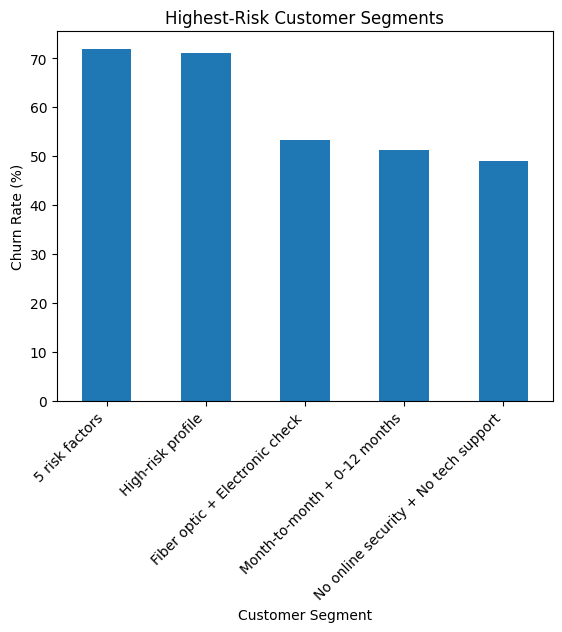

In [5]:
key_segments.sort_values("Churn_Rate_%", ascending=False).plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Highest-Risk Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## High-Risk Segment Findings

The highest-risk customer groups are customers with multiple churn risk factors. Customers with all 5 risk factors had a churn rate of 71.85%, and the combined high-risk profile had a churn rate of 71.16%.

Other major high-risk groups include fiber optic customers using electronic checks, month-to-month customers with 0-12 months of tenure, and customers without both online security and tech support.

These groups are important because they are specific enough to support targeted retention strategies.

## Final Model Performance

The modeling notebook selected Logistic Regression with a 0.55 threshold as the final churn prediction model.

In [6]:
final_model_summary

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.55,0.753016,0.524254,0.751337,0.617582,0.841639


In [7]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841639
1,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843366
2,Random Forest,0.782825,0.618881,0.473262,0.536364,0.823214
3,Dummy Baseline,0.734564,0.000000,0.000000,0.000000,0.500000


## Model Findings

The final selected model was Logistic Regression with a 0.55 prediction threshold.

This model achieved:

- 75.30% accuracy
- 52.43% precision
- 75.13% recall
- 61.76% F1-score
- 84.16% ROC-AUC

The model was selected because it provided the best balance for churn detection. In a retention problem, recall is especially important because the business wants to identify customers who are likely to leave before they actually churn.

## Business Recommendations

Based on the segment analysis and modeling results, the company should focus on customers who show multiple churn risk signals instead of treating all customers the same.

In [8]:
recommendations = pd.DataFrame({
    "Recommendation": [
        "Prioritize new month-to-month customers",
        "Target fiber optic customers using electronic checks",
        "Promote online security and tech support",
        "Use churn model scores for retention outreach",
        "Create onboarding follow-up for first-year customers"
    ],
    "Reason": [
        "Month-to-month customers with 0-12 months of tenure had a 51.35% churn rate.",
        "Fiber optic customers using electronic checks had a 53.23% churn rate.",
        "Customers without both online security and tech support had a 48.96% churn rate.",
        "The final model identified about 75% of churned customers in the test set.",
        "Newer customers were one of the highest-risk groups across the analysis."
    ],
    "Suggested_Action": [
        "Offer early contract incentives, loyalty discounts, or proactive check-ins.",
        "Review billing experience, payment friction, and service satisfaction for this group.",
        "Bundle support services or offer limited-time trials for high-risk customers.",
        "Rank customers by predicted churn probability and contact the highest-risk group first.",
        "Create a 30-day, 60-day, and 90-day onboarding support workflow."
    ]
})

recommendations

,Recommendation,Reason,Suggested_Action
0,Prioritize new month-to-month customers,Month-to-month customers with 0-12 months of t...,"Offer early contract incentives, loyalty disco..."
1,Target fiber optic customers using electronic ...,Fiber optic customers using electronic checks ...,"Review billing experience, payment friction, a..."
2,Promote online security and tech support,Customers without both online security and tec...,Bundle support services or offer limited-time ...
3,Use churn model scores for retention outreach,The final model identified about 75% of churne...,Rank customers by predicted churn probability ...
4,Create onboarding follow-up for first-year cus...,Newer customers were one of the highest-risk g...,"Create a 30-day, 60-day, and 90-day onboarding..."


In [9]:
pd.set_option("display.max_colwidth", None)

recommendations

,Recommendation,Reason,Suggested_Action
0,Prioritize new month-to-month customers,Month-to-month customers with 0-12 months of tenure had a 51.35% churn rate.,"Offer early contract incentives, loyalty discounts, or proactive check-ins."
1,Target fiber optic customers using electronic checks,Fiber optic customers using electronic checks had a 53.23% churn rate.,"Review billing experience, payment friction, and service satisfaction for this group."
2,Promote online security and tech support,Customers without both online security and tech support had a 48.96% churn rate.,Bundle support services or offer limited-time trials for high-risk customers.
3,Use churn model scores for retention outreach,The final model identified about 75% of churned customers in the test set.,Rank customers by predicted churn probability and contact the highest-risk group first.
4,Create onboarding follow-up for first-year customers,Newer customers were one of the highest-risk groups across the analysis.,"Create a 30-day, 60-day, and 90-day onboarding support workflow."


## Recommendation Summary

The recommendations focus on the customer groups with the highest churn risk. The goal is to use both the segment analysis and the predictive model to guide retention actions.

The company should prioritize customers who have multiple risk signals, especially new month-to-month customers, fiber optic customers using electronic checks, and customers without support-related services.

In [10]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
if not output_dir.exists() and Path("../outputs").exists():
    output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

recommendations.to_csv(output_dir / "churn_recommendations.csv", index=False)

print(f"Recommendations saved to {output_dir}")


Recommendations saved.


In [11]:
recommendation_priority = pd.DataFrame({
    "Priority": [
        "High",
        "High",
        "High",
        "Medium",
        "Medium"
    ],
    "Focus_Area": [
        "New month-to-month customers",
        "Fiber optic + electronic check customers",
        "Customers without online security and tech support",
        "Model-based retention outreach",
        "First-year onboarding"
    ],
    "Why_It_Matters": [
        "This segment had a 51.35% churn rate.",
        "This segment had a 53.23% churn rate.",
        "This segment had a 48.96% churn rate.",
        "The final model identified about 75% of churned customers.",
        "New customers showed consistently higher churn risk."
    ],
    "Business_Action": [
        "Offer contract incentives, early loyalty discounts, or proactive check-ins.",
        "Review payment experience, service satisfaction, and billing friction.",
        "Offer support-service bundles or limited-time trials.",
        "Rank customers by churn probability and contact the highest-risk customers first.",
        "Create 30-day, 60-day, and 90-day onboarding follow-ups."
    ]
})

recommendation_priority

,Priority,Focus_Area,Why_It_Matters,Business_Action
0,High,New month-to-month customers,This segment had a 51.35% churn rate.,"Offer contract incentives, early loyalty discounts, or proactive check-ins."
1,High,Fiber optic + electronic check customers,This segment had a 53.23% churn rate.,"Review payment experience, service satisfaction, and billing friction."
2,High,Customers without online security and tech support,This segment had a 48.96% churn rate.,Offer support-service bundles or limited-time trials.
3,Medium,Model-based retention outreach,The final model identified about 75% of churned customers.,Rank customers by churn probability and contact the highest-risk customers first.
4,Medium,First-year onboarding,New customers showed consistently higher churn risk.,"Create 30-day, 60-day, and 90-day onboarding follow-ups."


In [12]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
if not output_dir.exists() and Path("../outputs").exists():
    output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

recommendation_priority.to_csv(output_dir / "recommendation_priority.csv", index=False)

print(f"Recommendation priority table saved to {output_dir}")


Recommendation priority table saved.


## Executive Summary

This project analyzed customer churn for a telecommunications company using exploratory data analysis, customer segmentation, and machine learning.

The overall churn rate was 26.54%. Churn was highest among customers with month-to-month contracts, short tenure, fiber optic internet service, electronic check payment methods, higher monthly charges, and missing support services such as online security and tech support.

The strongest high-risk groups were customers with all 5 risk factors, with a churn rate of 71.85%, and the combined high-risk profile, with a churn rate of 71.16%. These results show that churn risk increases when multiple risk factors appear together.

Several machine learning models were trained to predict churn. Logistic Regression with a 0.55 threshold was selected as the final model because it provided the best balance for churn detection. The final model achieved 75.30% accuracy, 52.43% precision, 75.13% recall, 61.76% F1-score, and 84.16% ROC-AUC.

The final recommendation is to use targeted retention strategies rather than treating all customers the same. The company should prioritize new month-to-month customers, fiber optic customers using electronic checks, customers without support services, and customers flagged by the churn model as high risk.


## Project Conclusion

This multi-notebook project showed how customer churn can be analyzed from both a business and machine learning perspective.

The EDA notebook cleaned the data and identified the main churn patterns. The insights notebook grouped customers into meaningful segments and showed that churn risk increases sharply when multiple risk factors are combined. The modeling notebook trained several classification models and selected Logistic Regression with a 0.55 threshold as the final churn prediction model. This final recommendations notebook connected the segment findings and model results to practical retention actions.

The main business takeaway is that churn is not random. Customers with short tenure, month-to-month contracts, fiber optic service, electronic check payments, and missing support services are much more likely to leave. By identifying these customers earlier, the company can focus retention efforts where they are most likely to matter.

In [13]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
if not output_dir.exists() and Path("../outputs").exists():
    output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

recommendations.to_csv(output_dir / "churn_recommendations.csv", index=False)
recommendation_priority.to_csv(output_dir / "recommendation_priority.csv", index=False)

print(f"Final recommendation outputs saved to {output_dir}")


Final recommendation outputs saved.
